In [1]:
"""
O2O优惠券个性化投放 - 决策树 & XGBoost 分类模型（终极兼容版）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve)
from sklearn.impute import SimpleImputer
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"XGBoost版本: {xgb.__version__}")

# ============================================
# 1. 读取数据
# ============================================

print("=" * 60)
print("【1. 读取训练数据】")
print("=" * 60)

train_path = './tmp/train_class.csv'
df = pd.read_csv(train_path)

print(f"数据形状: {df.shape}")

XGBoost版本: 3.1.3
【1. 读取训练数据】
数据形状: (947279, 20)


In [2]:
# ============================================
# 2. 准备特征和标签
# ============================================

print("\n" + "=" * 60)
print("【2. 准备特征和标签】")
print("=" * 60)

exclude_cols = ['user_id', 'merchant_id', 'coupon_id', 'date', 'date_received', 
                'class', 'consume_gap', 'dataset', 'discount_rate']

feature_cols = [col for col in df.columns 
                if col not in exclude_cols and df[col].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f"特征数量: {len(feature_cols)}")

X_raw = df[feature_cols].copy()
y = df['class'].copy()


【2. 准备特征和标签】
特征数量: 13


In [3]:
# ============================================
# 3. 空值填补
# ============================================

print("\n" + "=" * 60)
print("【3. 空值填补】")
print("=" * 60)

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols, index=X_raw.index)

print(f"填补后缺失值数量: {X.isnull().sum().sum()}")

imputer_path = r"F:\my item\O2O优惠券个性化投放\【下载】项目数据文件\imputer.pkl"
joblib.dump(imputer, imputer_path)

print(f"\n标签分布:\n{y.value_counts()}")


【3. 空值填补】
填补后缺失值数量: 0

标签分布:
class
0    890219
1     57060
Name: count, dtype: int64


In [4]:
# ============================================
# 4. 划分训练集和验证集
# ============================================

print("\n" + "=" * 60)
print("【4. 划分训练集和验证集】")
print("=" * 60)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")


【4. 划分训练集和验证集】
训练集: (757823, 13), 验证集: (189456, 13)


In [5]:
# ============================================
# 5. 决策树分类模型
# ============================================

print("\n" + "=" * 60)
print("【5. 决策树分类模型】")
print("=" * 60)

dt_param_grid = {
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [50, 100, 200],
    'min_samples_leaf': [20, 50, 100]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f"\n最优参数: {dt_grid.best_params_}")
print(f"最优CV-AUC: {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_

# 预测和评估
y_pred_dt = dt_best.predict(X_val)
y_prob_dt = dt_best.predict_proba(X_val)[:, 1]

print("\n【决策树评估】")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred_dt):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_dt):.4f}")

# 特征重要性
feature_importance_dt = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n【决策树特征重要性 Top 15】")
print(feature_importance_dt.head(15).to_string(index=False))


【5. 决策树分类模型】
Fitting 3 folds for each of 36 candidates, totalling 108 fits

最优参数: {'max_depth': 15, 'min_samples_leaf': 100, 'min_samples_split': 50}
最优CV-AUC: 0.9839

【决策树评估】
Accuracy:  0.9267
Precision: 0.4505
Recall:    0.9869
F1-Score:  0.6186
AUC:       0.9839

【决策树特征重要性 Top 15】
                             feature  importance
       user_mean_use_coupon_interval    0.926715
  user_receive_coupon_unused_times_x    0.015502
               user_use_coupon_times    0.013840
  user_receive_coupon_unused_times_y    0.009375
merchant_mean_launch_coupon_interval    0.008375
           coupon_fifteen_used_count    0.007844
                    coupon_used_rate    0.006355
                            distance    0.005878
   merchant_launch_coupon_used_count    0.001758
    merchant_launch_coupon_used_rate    0.001480
        merchant_launch_coupon_count    0.001191
                user_use_coupon_rate    0.001051
                  user_consume_times    0.000636


In [6]:
# ============================================
# 6. XGBoost分类模型
# ============================================

print("\n" + "=" * 60)
print("【6. XGBoost分类模型】")
print("=" * 60)

# 计算类别权重
scale_pos_weight = len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# 基础XGBoost - 使用最基础的fit，不传递任何额外参数
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# 最基础的fit，不传递eval_set/callbacks/early_stopping等任何可能报错的参数
print("\n训练基础XGBoost模型...")
xgb_base.fit(X_train, y_train)

# 预测
y_pred_xgb = xgb_base.predict(X_val)
y_prob_xgb = xgb_base.predict_proba(X_val)[:, 1]

print("\n【XGBoost基础模型评估】")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred_xgb):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_xgb):.4f}")

# XGBoost参数调优（GridSearchCV不需要eval_set）
print("\n【XGBoost参数调优】")

xgb_param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
    xgb_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"\n最优参数: {xgb_grid.best_params_}")
print(f"最优CV-AUC: {xgb_grid.best_score_:.4f}")

# 最优模型
xgb_best = xgb_grid.best_estimator_
y_pred_xgb_best = xgb_best.predict(X_val)
y_prob_xgb_best = xgb_best.predict_proba(X_val)[:, 1]

print("\n【XGBoost最优模型评估】")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_xgb_best):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb_best):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_xgb_best):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred_xgb_best):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_xgb_best):.4f}")

# 特征重要性
feature_importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n【XGBoost特征重要性 Top 15】")
print(feature_importance_xgb.head(15).to_string(index=False))


【6. XGBoost分类模型】
scale_pos_weight: 15.60

训练基础XGBoost模型...

【XGBoost基础模型评估】
Accuracy:  0.9293
Precision: 0.4597
Recall:    0.9906
F1-Score:  0.6280
AUC:       0.9864

【XGBoost参数调优】
Fitting 3 folds for each of 24 candidates, totalling 72 fits

最优参数: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
最优CV-AUC: 0.9871

【XGBoost最优模型评估】
Accuracy:  0.9330
Precision: 0.4731
Recall:    0.9850
F1-Score:  0.6392
AUC:       0.9870

【XGBoost特征重要性 Top 15】
                             feature  importance
       user_mean_use_coupon_interval    0.793068
  user_receive_coupon_unused_times_x    0.047868
               user_use_coupon_times    0.040511
  user_receive_coupon_unused_times_y    0.029689
                            distance    0.018731
           coupon_fifteen_used_count    0.018330
merchant_mean_launch_coupon_interval    0.015050
        merchant_launch_coupon_count    0.011053
   merchant_launch_coupon_used_count    0.008595
                user_use_coupon_rat


【7. 模型对比可视化】


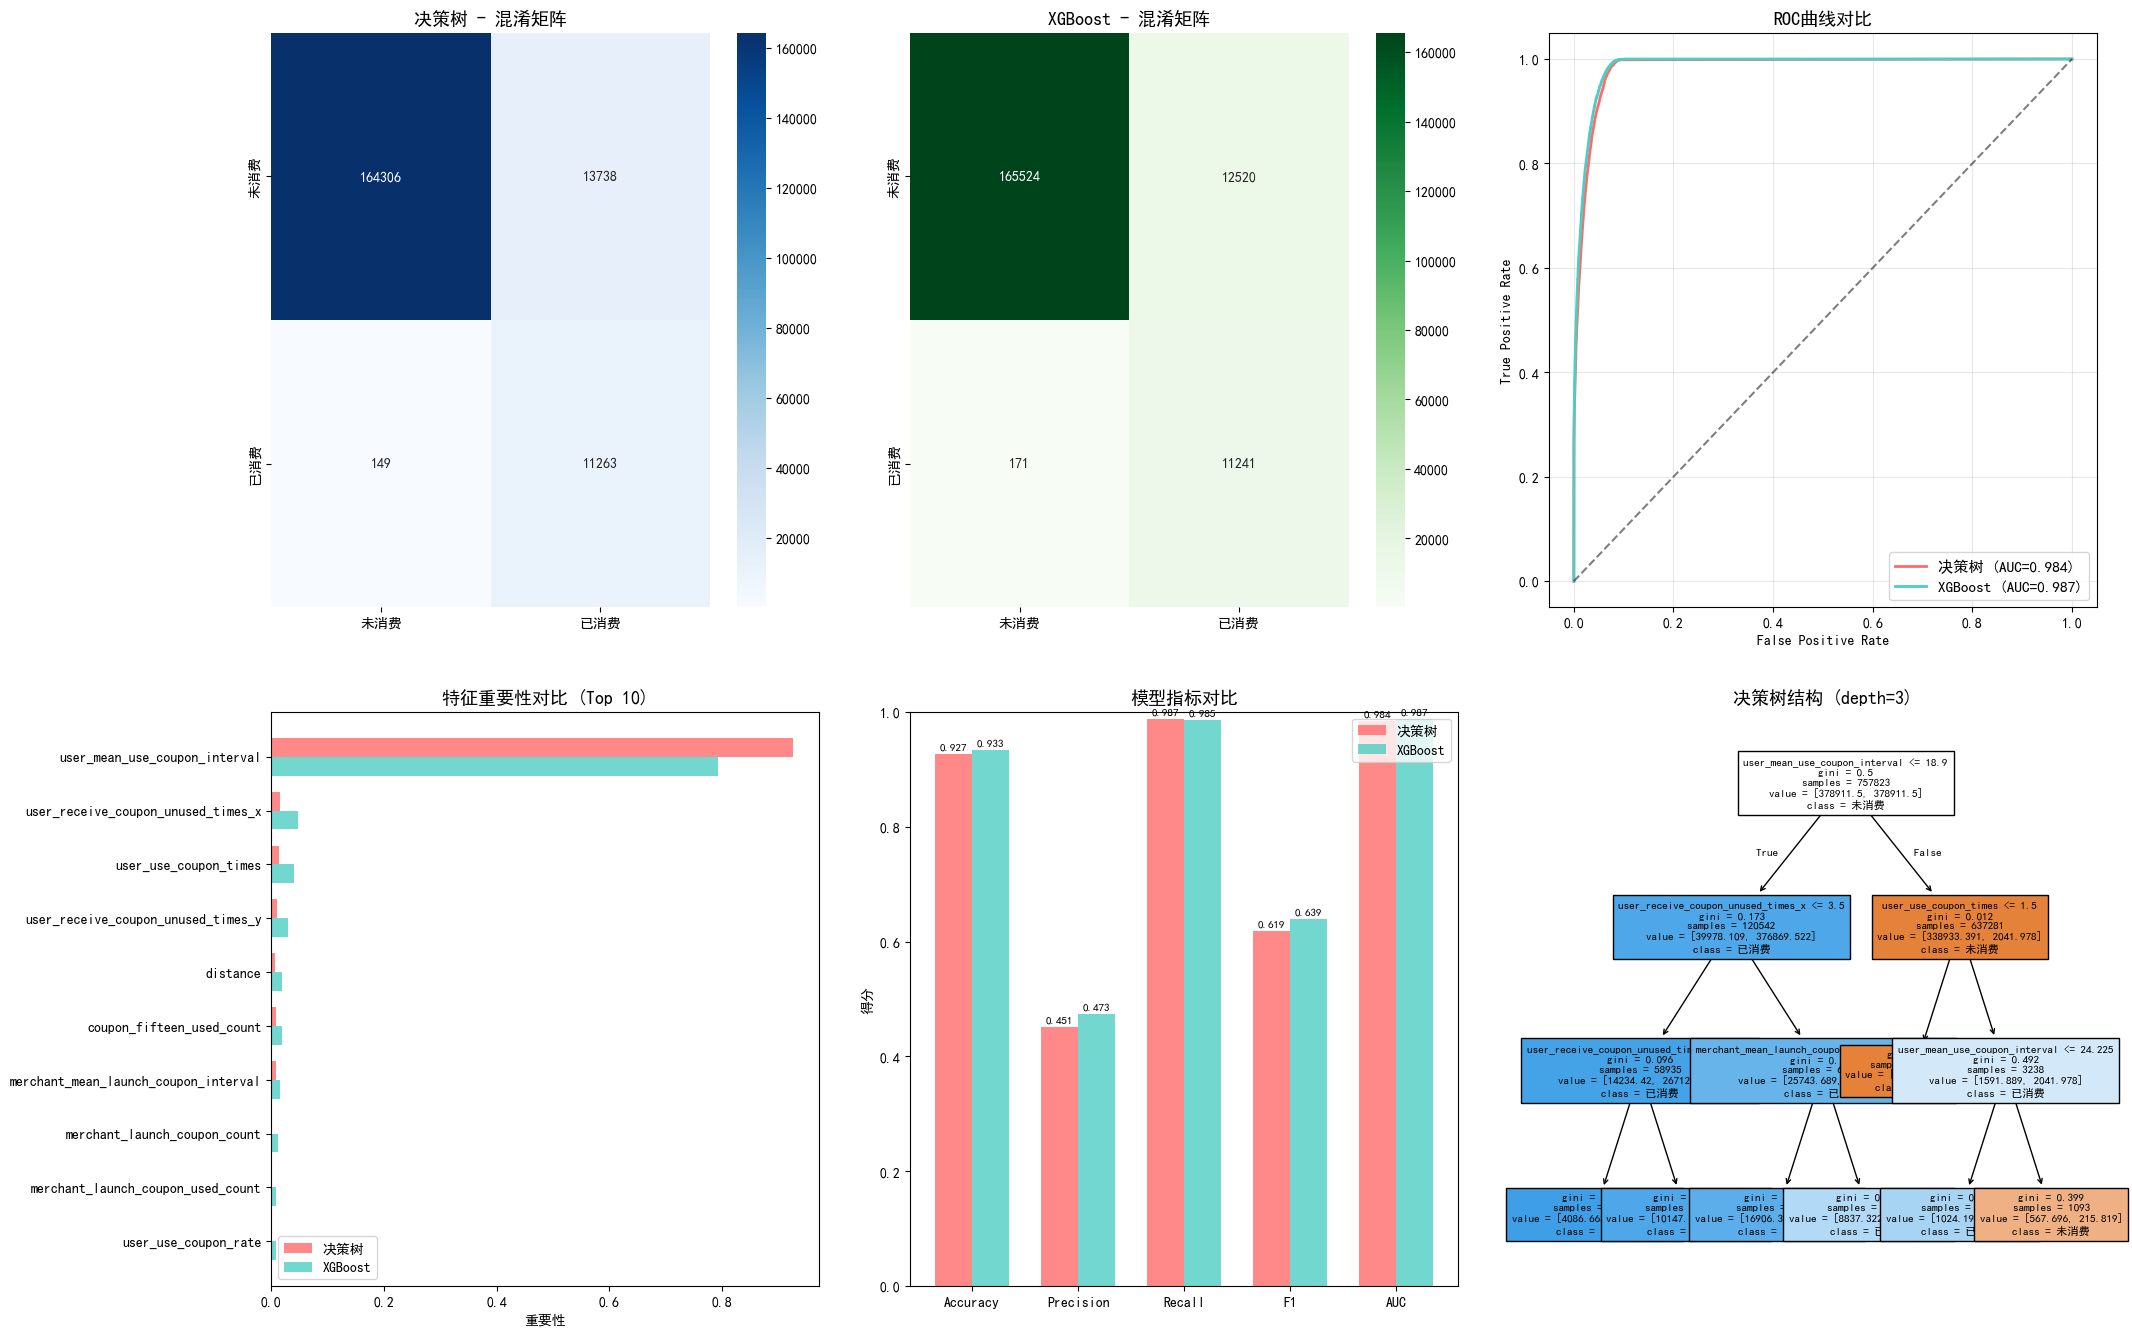


可视化已保存


In [7]:
# ============================================
# 7. 可视化
# ============================================

print("\n" + "=" * 60)
print("【7. 模型对比可视化】")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# 混淆矩阵 - 决策树
ax1 = axes[0, 0]
cm_dt = confusion_matrix(y_val, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['未消费', '已消费'], yticklabels=['未消费', '已消费'])
ax1.set_title('决策树 - 混淆矩阵', fontsize=13, fontweight='bold')

# 混淆矩阵 - XGBoost
ax2 = axes[0, 1]
cm_xgb = confusion_matrix(y_val, y_pred_xgb_best)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['未消费', '已消费'], yticklabels=['未消费', '已消费'])
ax2.set_title('XGBoost - 混淆矩阵', fontsize=13, fontweight='bold')

# ROC曲线
ax3 = axes[0, 2]
fpr_dt, tpr_dt, _ = roc_curve(y_val, y_prob_dt)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb_best)

ax3.plot(fpr_dt, tpr_dt, label=f'决策树 (AUC={roc_auc_score(y_val, y_prob_dt):.3f})', 
         color='#FF6B6B', linewidth=2)
ax3.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_val, y_prob_xgb_best):.3f})', 
         color='#4ECDC4', linewidth=2)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC曲线对比', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# 特征重要性对比
ax4 = axes[1, 0]
top10 = feature_importance_xgb.head(10)['feature'].tolist()
dt_top10 = feature_importance_dt[feature_importance_dt['feature'].isin(top10)]
dt_top10 = dt_top10.set_index('feature').reindex(top10).reset_index()

x_pos = np.arange(len(top10))
width = 0.35
ax4.barh(x_pos - width/2, dt_top10['importance'], width, label='决策树', color='#FF6B6B', alpha=0.8)
ax4.barh(x_pos + width/2, feature_importance_xgb.head(10)['importance'], width,
         label='XGBoost', color='#4ECDC4', alpha=0.8)
ax4.set_yticks(x_pos)
ax4.set_yticklabels(top10, fontsize=10)
ax4.set_xlabel('重要性')
ax4.set_title('特征重要性对比 (Top 10)', fontsize=13, fontweight='bold')
ax4.legend()
ax4.invert_yaxis()

# 指标对比
ax5 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
dt_scores = [accuracy_score(y_val, y_pred_dt), precision_score(y_val, y_pred_dt),
             recall_score(y_val, y_pred_dt), f1_score(y_val, y_pred_dt),
             roc_auc_score(y_val, y_prob_dt)]
xgb_scores = [accuracy_score(y_val, y_pred_xgb_best), precision_score(y_val, y_pred_xgb_best),
              recall_score(y_val, y_pred_xgb_best), f1_score(y_val, y_pred_xgb_best),
              roc_auc_score(y_val, y_prob_xgb_best)]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax5.bar(x - width/2, dt_scores, width, label='决策树', color='#FF6B6B', alpha=0.8)
bars2 = ax5.bar(x + width/2, xgb_scores, width, label='XGBoost', color='#4ECDC4', alpha=0.8)
ax5.set_ylabel('得分')
ax5.set_title('模型指标对比', fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.legend()
ax5.set_ylim(0, 1)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# 决策树可视化
ax6 = axes[1, 2]
top5 = feature_importance_dt.head(5)['feature'].tolist()
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt_viz.fit(X_train[top5], y_train)
plot_tree(dt_viz, feature_names=top5, class_names=['未消费', '已消费'],
          filled=True, ax=ax6, fontsize=8)
ax6.set_title('决策树结构 (depth=3)', fontsize=13, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig('model_comparison_final.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n可视化已保存")

In [8]:
# ============================================
# 8. 保存模型
# ============================================

print("\n" + "=" * 60)
print("【8. 保存模型】")
print("=" * 60)

joblib.dump(dt_best, r"F:\my item\O2O优惠券个性化投放\【下载】项目数据文件\dt_model.pkl")
joblib.dump(xgb_best, r"F:\my item\O2O优惠券个性化投放\【下载】项目数据文件\xgb_model.pkl")
joblib.dump(imputer, r"F:\my item\O2O优惠券个性化投放\【下载】项目数据文件\imputer.pkl")
joblib.dump(feature_cols, r"F:\my item\O2O优惠券个性化投放\【下载】项目数据文件\feature_list.pkl")

print("模型保存完成！")


【8. 保存模型】
模型保存完成！


In [9]:
# ============================================
# 9. 总结
# ============================================

print("\n" + "=" * 60)
print("【9. 模型对比总结】")
print("=" * 60)

comparison = pd.DataFrame({
    '指标': metrics,
    '决策树': [f'{s:.4f}' for s in dt_scores],
    'XGBoost': [f'{s:.4f}' for s in xgb_scores]
})
print(comparison.to_string(index=False))

best_auc_dt = roc_auc_score(y_val, y_prob_dt)
best_auc_xgb = roc_auc_score(y_val, y_prob_xgb_best)

print(f"\n{'='*60}")
if best_auc_xgb > best_auc_dt:
    print(f"✅ 推荐模型: XGBoost (AUC: {best_auc_xgb:.4f})")
else:
    print(f"✅ 推荐模型: 决策树 (AUC: {best_auc_dt:.4f})")
print(f"{'='*60}")


【9. 模型对比总结】
       指标    决策树 XGBoost
 Accuracy 0.9267  0.9330
Precision 0.4505  0.4731
   Recall 0.9869  0.9850
       F1 0.6186  0.6392
      AUC 0.9839  0.9870

✅ 推荐模型: XGBoost (AUC: 0.9870)
